## Init

In [1]:
import os
import numpy as np
import itertools as it
import random
import pandas as pd
import multiprocess as mp
import time
import sys
import matplotlib.pyplot as plt

In [2]:
folder = "C:/Users/B00955739/Documents/Git/phd/Init/"

sys.path.append(folder)

import functions_v5 as fn

In [3]:
if_print = False

delta = 10**(-10)
log_a = 4
tent_a = 2 - delta
tent_b = 4
sluze_m = 0.8
sluze_p = 0.2
l_map = fn.log_map({"a": log_a})
t_map = fn.tent_map({"a": tent_a, "b": tent_b})
s_map = fn.sluze_map({"m": sluze_m,"p": sluze_p})
all_maps = [l_map, t_map, s_map]

min_dim = 1
max_dim = 10
dims = np.arange(min_dim, max_dim + 1)

epsilons = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
mat_types = ["NN", "FC", "FCD", "HC", "RAND"]

modelling_len = 10000
n_tests = 100
test_len = 100
testing_len = n_tests * test_len
discard = 10000
sim_len = modelling_len + testing_len + discard
analysis_dim = 0

In [4]:
print("Systems info:")
print("maps = {}".format([mp.name for mp in all_maps]))
print("dims = {}".format(dims))
print("epsilons = {}".format(epsilons))
print("matrices = {}".format(mat_types))

print("Simulation info:")
print("total length = {}".format(sim_len))
print("discard length = {}".format(discard))
print("modelling length = {}".format(modelling_len))
print("testing length = {}; {} series of length {}".format(testing_len, n_tests, test_len))

Systems info:
maps = ['log_map', 'tent_map', 'sluze_map']
dims = [ 1  2  3  4  5  6  7  8  9 10]
epsilons = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
matrices = ['NN', 'FC', 'FCD', 'HC', 'RAND']
Simulation info:
total length = 30000
discard length = 10000
modelling length = 10000
testing length = 10000; 100 series of length 100


In [5]:
run_name = "main_run_v1"

In [6]:
out_folder = "C:/Users/B00955739/OneDrive - Ulster University/Documents/PhD/Results/Predicting_predictability/"

In [7]:
sim_folder = out_folder + "Sims/" + run_name + "/"
if not os.path.exists(sim_folder):
    os.makedirs(sim_folder)

In [8]:
print("CSV output: {}".format(out_folder+run_name+".csv"))
print("Simulations output: {}".format(sim_folder))

CSV output: C:/Users/B00955739/OneDrive - Ulster University/Documents/PhD/Results/Predicting_predictability/main_run_v1.csv
Simulations output: C:/Users/B00955739/OneDrive - Ulster University/Documents/PhD/Results/Predicting_predictability/Sims/main_run_v1/


## Define Systems

In [9]:
system_list = []
cml_list = []

sv_seed = 100
mat_seed = 200
map_shuffle_seed = 300

for d in dims:
    for e in epsilons:
        for mt in mat_types:
            for map_counts in it.product(np.arange(0, d+1), repeat=len(all_maps)):
                ## map counts is a tuple (map_1_count, ..., map_N_count) where the counts are every value between 1 and dim
                if sum(map_counts) == d:
                    map_list = []
                    for map_id, map_count in enumerate(map_counts):
                        map_list.extend(map_count * [all_maps[map_id]]) ## add all_maps[map_id] to map_list map_count times
                    random.seed(map_shuffle_seed)
                    random.shuffle(map_list)
                    if mt == "HC" and fn.is_base2(d) == False:
                        continue
                    mat = fn.gen_matrix(typ=mt, d=d, e=e, seed=mat_seed, if_print=False)
                    cml_ = fn.CML(matrix=mat, map_list=map_list)
                    dup = False
                    if cml_ in cml_list:
                        dup = True
                    cml_list.append(cml_)
                    np.random.seed(sv_seed)
                    sv = np.round(np.random.rand(d), 5)
                    analysis_dim = np.random.randint(low=0, high=d)
                    sys_dict = {
                        "dim": d
                        ,"mat_type": mt
                        ,"epsilon": e
                        ,"map_list": map_list
                        ,"map_list_str": [(mp.name, mp.params) for mp in map_list]
                        ,"matrix": mat
                        ,"cml": cml_
                        ,"sv": sv
                        ,"duplicate": dup
                        ,"mat_seed": mat_seed
                        ,"sv_seed": sv_seed
                        ,"map_shuffle_seed": map_shuffle_seed
                        ,"total_sim_len": sim_len
                        ,"discard_len": discard
                        ,"modelling_len": modelling_len
                        ,"n_tests": n_tests
                        ,"test_len": test_len
                        ,"testing_len": testing_len
                        ,"analysis_dim": analysis_dim
                    }
                    
                    for map_id, map_count in enumerate(map_counts):
                        sys_dict["map_type_{}".format(map_id)] = all_maps[map_id].name
                        sys_dict["map_type_{}_params".format(map_id)] = all_maps[map_id].params
                        sys_dict["map_type_{}_count".format(map_id)] = map_count

                    sys_dict["n_unique_maps"] = len([mc for mc in map_counts if mc > 0])
                        
                    system_list.append(sys_dict)
                    mat_seed += 1
                    sv_seed += 1
                    map_shuffle_seed += 1

for idx, s_d in enumerate(system_list):
    s_d["system_id"] = idx
    s_d["sim_file"] = sim_folder + "system_" + str(idx) + ".npy"

In [10]:
system_df = pd.DataFrame(system_list)

In [11]:
unique_sys = [s_d for s_d in system_list if not s_d["duplicate"]]
print("{} total systems".format(len(system_list)))
print("{} duplicate systems removed".format(len(system_list) - len(unique_sys)))
print("{} unique systems".format(len(unique_sys)))

10881 total systems
360 duplicate systems removed
10521 unique systems


In [12]:
unique_sys_df = pd.DataFrame(unique_sys)
unique_sys_df.head()

,dim,mat_type,epsilon,map_list,map_list_str,matrix,cml,sv,duplicate,mat_seed,...,n_tests,test_len,testing_len,analysis_dim,map_type_{},map_type_{}_params,map_type_{}_count,n_unique_maps,system_id,sim_file
0,1,NN,0.1,[sluze_map],"[(sluze_map, {'m': 0.8, 'p': 0.2})]",[[1.0]],<functions_v5.CML object at 0x000001D8478D7710>,[0.5434],False,200,...,100,100,10000,0,sluze_map,"{'m': 0.8, 'p': 0.2}",1,1,0,C:/Users/B00955739/OneDrive - Ulster Universit...
1,1,NN,0.1,[tent_map],"[(tent_map, {'a': 1.9999999999, 'b': 4})]",[[1.0]],<functions_v5.CML object at 0x000001D847CF1490>,[0.5164],False,201,...,100,100,10000,0,sluze_map,"{'m': 0.8, 'p': 0.2}",0,1,1,C:/Users/B00955739/OneDrive - Ulster Universit...
2,1,NN,0.1,[log_map],"[(log_map, {'a': 4})]",[[1.0]],<functions_v5.CML object at 0x000001D847FC7750>,[0.59768],False,202,...,100,100,10000,0,sluze_map,"{'m': 0.8, 'p': 0.2}",0,1,2,C:/Users/B00955739/OneDrive - Ulster Universit...
3,2,NN,0.1,"[sluze_map, sluze_map]","[(sluze_map, {'m': 0.8, 'p': 0.2}), (sluze_map...","[[0.9, 0.1], [0.1, 0.9]]",<functions_v5.CML object at 0x000001D847F92CD0>,"[0.93059, 0.52271]",False,335,...,100,100,10000,0,sluze_map,"{'m': 0.8, 'p': 0.2}",2,1,135,C:/Users/B00955739/OneDrive - Ulster Universit...
4,2,NN,0.1,"[tent_map, sluze_map]","[(tent_map, {'a': 1.9999999999, 'b': 4}), (slu...","[[0.9, 0.1], [0.1, 0.9]]",<functions_v5.CML object at 0x000001D847F92B50>,"[0.07787, 0.81072]",False,336,...,100,100,10000,1,sluze_map,"{'m': 0.8, 'p': 0.2}",1,2,136,C:/Users/B00955739/OneDrive - Ulster Universit...


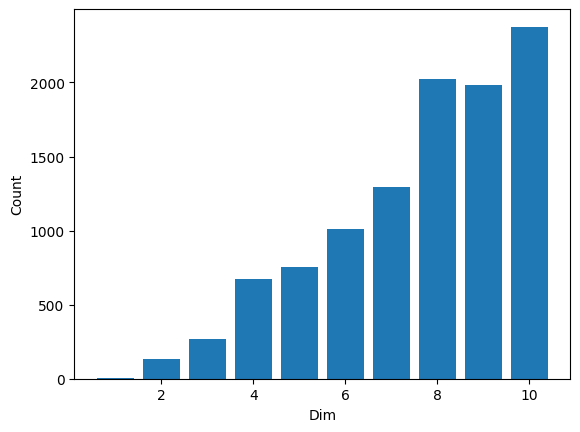

In [13]:
dim_arr = unique_sys_df.dim.to_numpy()
unique_dims, unique_counts = np.unique(dim_arr, return_counts=True)

plt.figure()
plt.bar(unique_dims, unique_counts)
plt.xlabel("Dim")
plt.ylabel("Count")
plt.show()
plt.close()

## Simulate Systems and Calculate Metrics

In [14]:
start_time = time.time()
pool = mp.Pool()
results = [pool.apply_async(fn.sim_system, args=(s_d,)) for s_d in unique_sys]
pool.close()
pool.join()
final_results = [result.get() for result in results]
end_time = time.time()
run_time = end_time-start_time
print("Full run time: {}s ({} hrs)".format(round(run_time, 4), round(run_time/(60*60), 4)))

Full run time: 14416.6744s (4.0046 hrs)


In [15]:
results_df = pd.DataFrame(final_results)

In [16]:
results_df.head()

,dim,mat_type,epsilon,map_list,map_list_str,matrix,cml,sv,duplicate,mat_seed,...,full_system_time,lyap_1,lyap_2,lyap_3,lyap_4,lyap_5,lyap_6,lyap_7,lyap_8,lyap_9
0,1,NN,0.1,[sluze_map],"[(sluze_map, {'m': 0.8, 'p': 0.2})]",[[1.0]],<functions_v5.CML object at 0x000001D84D6B1290>,[0.5434],False,200,...,10.559263,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,NN,0.1,[tent_map],"[(tent_map, {'a': 1.9999999999, 'b': 4})]",[[1.0]],<functions_v5.CML object at 0x000001D849A26050>,[0.5164],False,201,...,6.484154,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,NN,0.1,[log_map],"[(log_map, {'a': 4})]",[[1.0]],<functions_v5.CML object at 0x000001D849A1F9D0>,[0.59768],False,202,...,6.315509,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2,NN,0.1,"[sluze_map, sluze_map]","[(sluze_map, {'m': 0.8, 'p': 0.2}), (sluze_map...","[[0.9, 0.1], [0.1, 0.9]]",<functions_v5.CML object at 0x000001D849A25290>,"[0.93059, 0.52271]",False,335,...,NaN,-0.018366,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2,NN,0.1,"[tent_map, sluze_map]","[(tent_map, {'a': 1.9999999999, 'b': 4}), (slu...","[[0.9, 0.1], [0.1, 0.9]]",<functions_v5.CML object at 0x000001D849B80C90>,"[0.07787, 0.81072]",False,336,...,26.323180,-0.297401,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [17]:
print("Saving csv: {}".format(out_folder+run_name+".csv"))

results_df.to_csv(out_folder+run_name+".csv")

Saving csv: C:/Users/B00955739/OneDrive - Ulster University/Documents/PhD/Results/Predicting_predictability/main_run_v1.csv


In [18]:
print("real time: {}".format(round(run_time, 4)))
print("CPU time: {}".format(round(results_df.full_system_time.sum(), 4)))

real time: 14416.6744
CPU time: 328295.7085
